In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn.objects as so
url = 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/atencion-ciudadana/arbolado-publico-lineal/arbolado-publico-lineal-2017-2018.csv'
arbolado = pd.read_csv(url)
arbolado

<ipython-input-1-9688fd7e38b0>:7: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  arbolado = pd.read_csv(url)


,long,lat,nro_registro,tipo_activ,comuna,manzana,calle_nombre,calle_altura,calle_chapa,direccion_normalizada,ubicacion,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,26779,Lineal,1,NaN,Esmeralda,1000.0,1120.0,ESMERALDA 1120,NaN,Tipuana tipu,5.5,Ocupada,Regular,A nivel,88.0,34.0
1,-58.381532,-34.592319,30887,Lineal,1,NaN,Pellegrini Carlos,1300.0,1345.0,"PELLEGRINI, CARLOS 1345",Exacta,Peltophorum dubium,4.5,Ocupada,Regular,Elevada,6.0,5.0
2,-58.379103,-34.591939,30904,Lineal,1,NaN,Arroyo,800.0,848.0,ARROYO 848,Exacta,Fraxinus pennsylvanica,4,Ocupada,Regular,A nivel,7.0,6.0
3,-58.380710,-34.591548,31336,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LD,Fraxinus pennsylvanica,NaN,Ocupada,Regular,A nivel,9.0,29.0
4,-58.380710,-34.591548,31337,Lineal,1,NaN,Arroyo,900.0,932.0,ARROYO 932,LA,Jacaranda mimosifolia,NaN,Ocupada,Regular,A nivel,13.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370175,NaN,NaN,546140,Lineal,15,919,Guevara,1000.0,1000.0,NaN,LD3,Ceiba speciosa,3.3,Ocupada,Regular,A nivel,34.0,7.0
370176,NaN,NaN,546141,Lineal,15,919,Guevara,1000.0,1000.0,NaN,LD4,Melia azedarach,3.3,Ocupada,Regular,A nivel,45.0,8.0
370177,NaN,NaN,546142,Lineal,15,919,Guevara,1000.0,1000.0,NaN,LD5,Ceiba speciosa,3.3,Ocupada,Regular,A nivel,60.0,8.0
370178,NaN,NaN,546143,Lineal,15,919,Guevara,1000.0,1000.0,NaN,LD6,Ceiba speciosa,3.3,Ocupada,Regular,A nivel,64.0,8.0


#Limpieza de texto

In [ ]:
arbolado.shape
arbolado.ndim
arbolado.describe()
arbolado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364677 non-null  object 
 8   calle_chapa            363721 non-null  object 
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      370180 non-null  object 
 12  ancho_acera            367083 non-null  object 
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

In [ ]:
arbolado['calle_altura'] = pd.to_numeric(arbolado['calle_altura'], errors='coerce')
arbolado['calle_chapa'] = pd.to_numeric(arbolado['calle_chapa'], errors='coerce')

In [ ]:
arbolado['ancho_acera'] = arbolado['ancho_acera'].replace(0, np.nan)
arbolado['altura_arbol'] = arbolado['altura_arbol'].replace(0, np.nan)

arbolado['nombre_cientifico'] = arbolado['nombre_cientifico'].str.title()
arbolado['nombre_cientifico'] = arbolado['nombre_cientifico'].replace('No Identificado', np.nan)

arbolado['calle_nombre'] = arbolado['calle_nombre'].str.title()
arbolado['direccion_normalizada'] = arbolado['direccion_normalizada'].str.title()

arbolado = arbolado.drop_duplicates()

arbolado['especie_genero'] = arbolado['nombre_cientifico'].str.split().str[0]
arbolado['tiene_altura'] = ~arbolado['altura_arbol'].isna()

arbolado["ancho_acera"] = pd.to_numeric(arbolado["ancho_acera"], errors="coerce")


arbolado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364312 non-null  float64
 8   calle_chapa            363657 non-null  float64
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      360769 non-null  object 
 12  ancho_acera            366269 non-null  float64
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

#Exploración
**1. ¿Cuantos registros de arboles hay en total en el dataset?**

In [ ]:
print(len(arbolado))

370180


**2. ¿Cuáles son las especies más frecuentes en el arbolado de la ciudad?**

In [ ]:
especies_comunes = arbolado['nombre_cientifico'].value_counts().head(10)
print(especies_comunes)

nombre_cientifico
Fraxinus Pennsylvanica    133609
Platanus X Acerifolia      32319
Ficus Benjamina            22508
Tilia X Moltkei            15605
Melia Azedarach            14901
Jacaranda Mimosifolia      13872
Lagerstroemia Indica       11886
Fraxinus Americana         10119
Tipuana Tipu                9330
Ligustrum Lucidum           8958
Name: count, dtype: int64


Veamoslo en un grafico

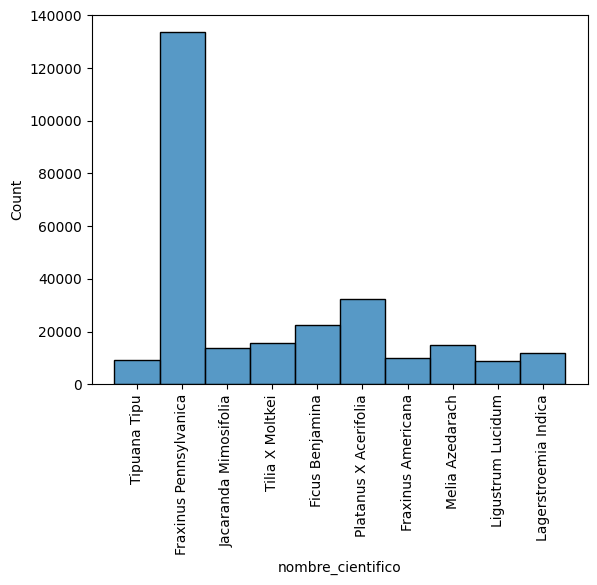

In [ ]:

especies_comunes = arbolado['nombre_cientifico'].value_counts().head(10)

sns.histplot(data=arbolado[arbolado['nombre_cientifico'].isin(especies_comunes.index)],
             x='nombre_cientifico',
             bins=len(especies_comunes),
             discrete=True)

plt.xticks(rotation=90)
plt.show()

#Visualización

**1. Generá un gráfico que muestre la cantidad de árboles por barrio**

In [ ]:
arboles_por_barrio = arbolado['comuna'].value_counts().head(10)
arboles_por_barrio

,count
comuna,
12,38818
11,37340
9,36405
10,33421
4,32346
15,29587
13,28287
7,25608
14,22417


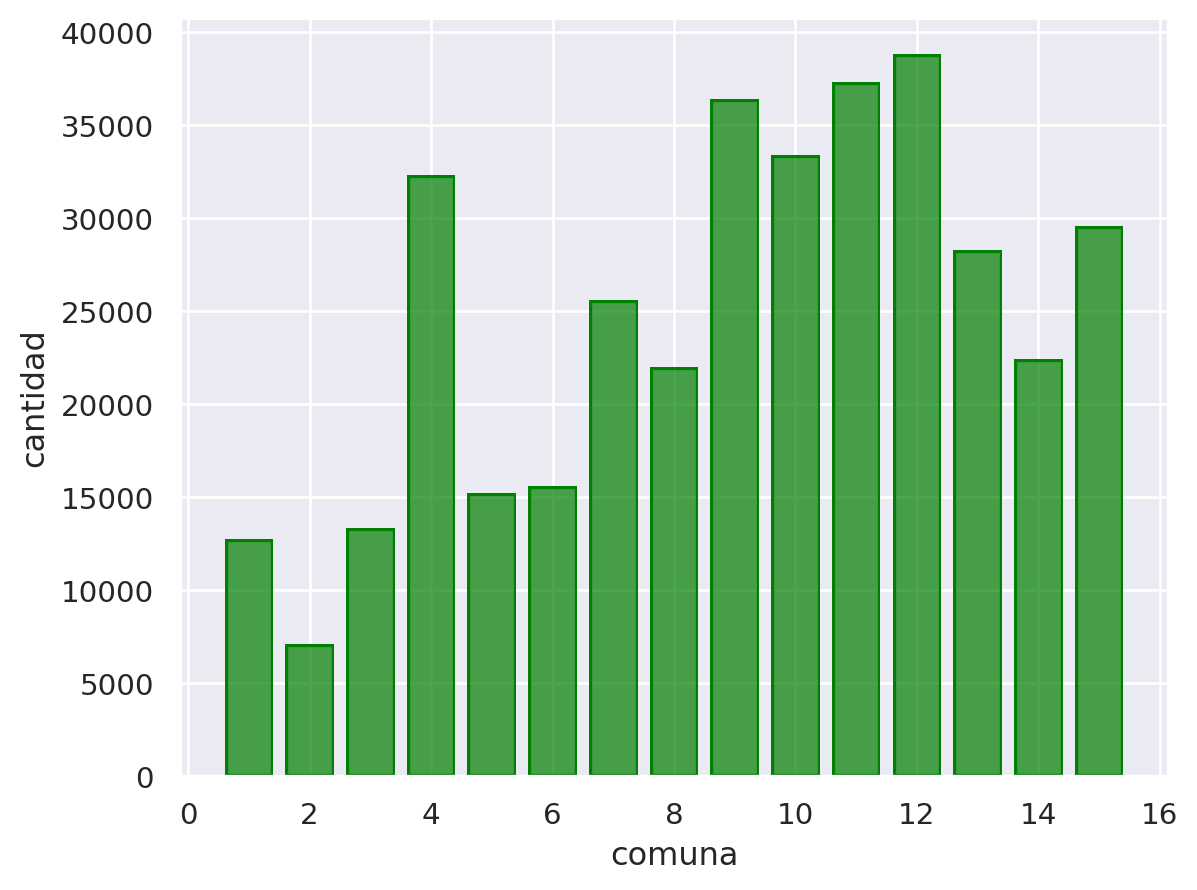

In [ ]:
arboles_por_comuna = arbolado['comuna'].value_counts()
comunas = arboles_por_comuna.reset_index()
comunas.columns = ['comuna', 'cantidad']
so.Plot(data= comunas , x='comuna', y='cantidad').add(so.Bar( color="green"))

###2. Hacé una visualización que relacione el diámetro del tronco con la altura del árbol.

<Axes: xlabel='diametro_altura_pecho', ylabel='altura_arbol'>

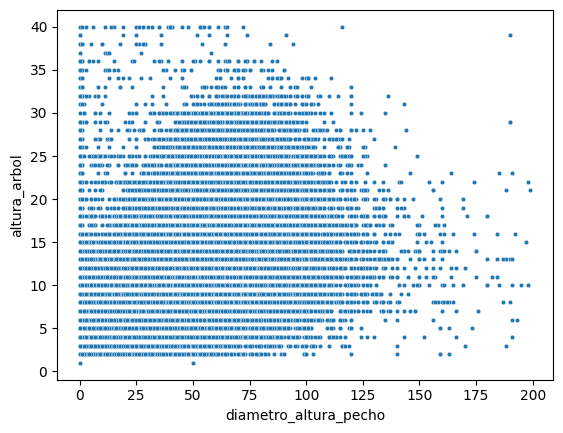

In [ ]:
sns.scatterplot(x='diametro_altura_pecho', y='altura_arbol', data=arbolado, s=10)

In [ ]:
numericas = arbolado.select_dtypes(include=['float64', 'int64']).columns
categoricas = arbolado.select_dtypes(include=['object']).columns


print("Descripción estadística de columnas numéricas:")
print(arbolado[numericas].describe())

print("\nDescripción estadística de columnas categóricas:")
for col in categoricas:
    print(f"\nColumna: {col}")
    print(f"Valores únicos: {arbolado[col].nunique()}")
    print(f"Moda: {arbolado[col].mode()[0]}")
    print(f"Conteo de valores más frecuentes:\n{arbolado[col].value_counts().head(5)}")

Descripción estadística de columnas numéricas:
                long            lat         comuna  calle_altura  \
count  354838.000000  354838.000000  370180.000000  3.643120e+05   
mean      -58.458791     -34.612473       9.143735  3.107528e+03   
std         0.041514       0.033695       3.876242  1.187194e+05   
min       -58.530458     -34.697333       1.000000  0.000000e+00   
25%       -58.491269     -34.637834       6.000000  1.200000e+03   
50%       -58.465865     -34.615023      10.000000  2.400000e+03   
75%       -58.428583     -34.586580      12.000000  3.800000e+03   
max       -58.354003     -34.535972      15.000000  3.900515e+07   

        calle_chapa    ancho_acera  diametro_altura_pecho   altura_arbol  
count  3.636570e+05  366269.000000          369894.000000  365858.000000  
mean   2.675298e+03       3.785710              31.986864       9.036132  
std    4.177803e+03       1.334402              21.267623       4.894625  
min    0.000000e+00       0.400000      

<ipython-input-11-6b08c600bb92>:12: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  print(f"Moda: {arbolado[col].mode()[0]}")


Moda: 26779
Conteo de valores más frecuentes:
nro_registro
546144    1
26779     1
30887     1
30904     1
545929    1
Name: count, dtype: int64

Columna: tipo_activ
Valores únicos: 6
Moda: Lineal
Conteo de valores más frecuentes:
tipo_activ
Lineal      365629
Lineal        4301
lineal         167
Lineal          35
calle           33
Name: count, dtype: int64

Columna: manzana
Valores únicos: 1843
Moda: 568
Conteo de valores más frecuentes:
manzana
568    1102
16      462
948     455
467     421
874     412
Name: count, dtype: int64

Columna: calle_nombre
Valores únicos: 2208
Moda: Del Libertador, Av
Conteo de valores más frecuentes:
calle_nombre
Del Libertador, Av           1267
Alberdi Juan Bautista Av.    1153
Directorio Av.               1138
Rivadavia, Av                1133
Yerbal                       1128
Name: count, dtype: int64

Columna: direccion_normalizada
Valores únicos: 248939
Moda: España Av.
Conteo de valores más frecuentes:
direccion_normalizada
España Av.          

In [ ]:
import pandas as pd

tabla = pd.crosstab(arbolado['comuna'], arbolado['nombre_cientifico'])

proporciones = tabla.div(tabla.sum(axis=1), axis=0)

especies_interes = ['Fraxinus Pennsylvanica', 'Platanus X Acerifolia', 'Jacaranda Mimosifolia',
                    'Tipuana Tipu', 'Fraxinus Excelsior']

resultados = pd.DataFrame({
    'Comuna con Mayor Proporción': proporciones[especies_interes].idxmax(),
    'Proporción Máxima': proporciones[especies_interes].max()
})

print("Comunas con mayor proporción para las especies con mayor variación:")
print(resultados)

Comunas con mayor proporción para las especies con mayor variación:
                        Comuna con Mayor Proporción  Proporción Máxima
nombre_cientifico                                                     
Fraxinus Pennsylvanica                            3           0.549086
Platanus X Acerifolia                            14           0.159629
Jacaranda Mimosifolia                             1           0.133237
Tipuana Tipu                                     14           0.114647
Fraxinus Excelsior                                3           0.076116


In [ ]:
arbolado.groupby("nombre_cientifico")["ancho_acera"].describe()

,count,mean,std,min,25%,50%,75%,max
nombre_cientifico,,,,,,,,
Abies Alba,6.0,3.533333,2.254477,2.0,2.200,3.0,3.200,8.0
Abutilon Grandiflorum,19.0,3.757895,0.932330,2.8,3.000,3.0,4.400,5.6
Abutilon Pictum,1.0,2.600000,NaN,2.6,2.600,2.6,2.600,2.6
Acacia Baileyana,37.0,3.991892,1.017180,2.4,3.200,4.4,4.400,6.5
Acacia Caven,86.0,3.779651,1.082301,1.6,3.200,3.7,4.400,8.0
...,...,...,...,...,...,...,...,...
Washingtonia Filifera,96.0,4.808854,3.089549,1.8,3.575,4.4,4.525,28.0
Washingtonia Robusta,89.0,4.383146,1.723846,1.5,3.200,4.4,4.500,13.0
Yucca Gloriosa,5.0,3.000000,1.280625,2.0,2.000,2.2,4.400,4.4


Vemos los intervalos apropiados

# ANALISIS
**1. ¿Existen especies que se planten preferentemente en ciertos barrios o comunas?**


In [ ]:
top10 = arbolado["nombre_cientifico"].value_counts().head(10).index
top10_df = arbolado[arbolado["nombre_cientifico"].isin(top10)]
tabla = pd.crosstab(top10_df["nombre_cientifico"], top10_df["comuna"])
tabla.T

nombre_cientifico,Ficus Benjamina,Fraxinus Americana,Fraxinus Pennsylvanica,Jacaranda Mimosifolia,Lagerstroemia Indica,Ligustrum Lucidum,Melia Azedarach,Platanus X Acerifolia,Tilia X Moltkei,Tipuana Tipu
comuna,,,,,,,,,,
1,626,192,4107,1660,357,123,43,1516,650,449
2,770,103,2508,483,284,49,40,697,418,127
3,883,111,7120,400,250,211,202,658,174,51
4,1358,1230,15306,907,634,622,1511,2290,754,1038
5,1091,592,6303,453,322,215,576,1756,409,76
6,1104,388,6058,582,302,250,460,1030,691,618
7,1716,1096,9728,945,841,566,891,1811,995,514
8,1173,362,6649,701,1005,1717,1038,956,963,175
9,2443,1459,11235,810,1501,1976,1443,2624,1698,539


Sí, existen especies que preferentemente se plantan en ciertas comunas por ejemplo *Ligustrum Lucidum* está mucho más presente en las comunas 8,9 y 10 en comparación a las demas comunas. Otro ejemplo sería *Fraxinus Americana* que se encuentra bastante presente en las comunes 9 y 11.

**2. ¿Existe relación entre el ancho de acera y el tipo de especie plantada?**





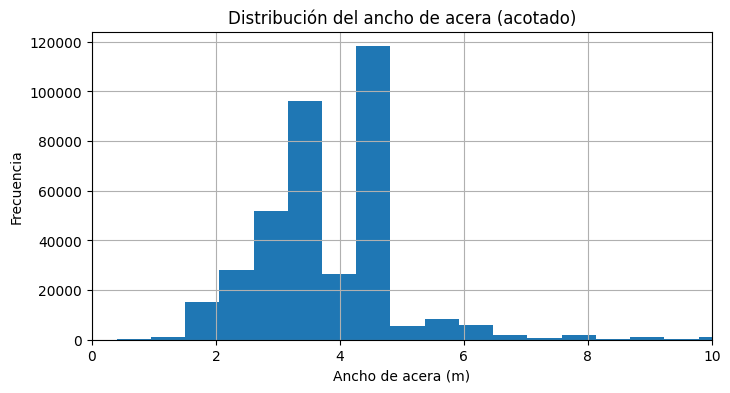

In [ ]:
import matplotlib.pyplot as plt

arbolado["ancho_acera"].hist(bins=50, figsize=(8, 4))
plt.xlabel("Ancho de acera (m)")
plt.ylabel("Frecuencia")
plt.title("Distribución del ancho de acera (acotado)")
plt.xlim(0, 10)
plt.show()

Intentamos ver la distribución con intervalos de a 2m

<ipython-input-32-9af877311640>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top_species.groupby(["rango_acera", "nombre_cientifico"])


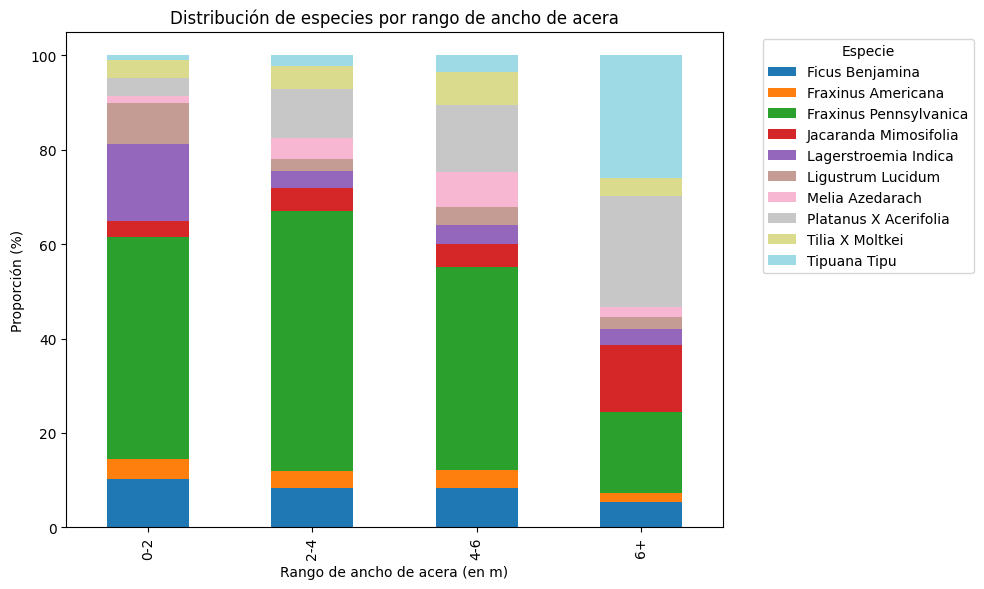

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


bins = [0, 2, 4, 6, arbolado["ancho_acera"].max()]
labels = ["0-2", "2-4", "4-6", "6+"]


arbolado["rango_acera"] = pd.cut(arbolado["ancho_acera"], bins=bins, labels=labels, include_lowest=True)


top_species = arbolado["nombre_cientifico"].value_counts().head(10).index
df_top_species = arbolado[arbolado["nombre_cientifico"].isin(top_species)]


proporciones = (
    df_top_species.groupby(["rango_acera", "nombre_cientifico"])
    .size()
    .unstack(level=1, fill_value=0)
    .apply(lambda x: 100 * x / x.sum(), axis=1)
)


proporciones.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.ylabel("Proporción (%)")
plt.xlabel("Rango de ancho de acera (en m)")
plt.title("Distribución de especies por rango de ancho de acera")
plt.legend(title="Especie", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Vemos que en aceras anchas,Fraxinus Pennsylvanica toma menos relevancia y da lugar a especies como tipuana tipu, Jacaranda mimosifolia y platanus x acerifolia. Lagerstroemia Indica toma relevancia en anchos de acera cortos, al igual que ligustrum lucidum.

<ipython-input-33-61a2a3603de3>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arbolado_top.groupby(["rango_acera", "nombre_cientifico"])


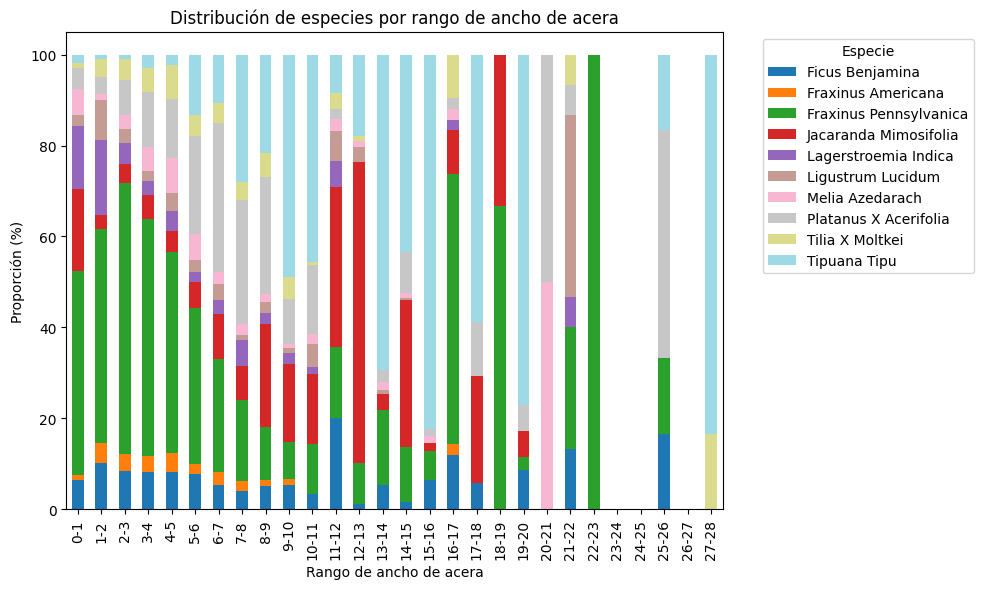

In [ ]:
valor_max = arbolado["ancho_acera"].max()
intervalos = list(np.arange(0, valor_max + 1, 1))
intervalos[-1] = valor_max


etiquetas = [f"{i}-{i+1}" for i in range(len(intervalos) - 1)]


arbolado["rango_acera"] = pd.cut(arbolado["ancho_acera"], bins=intervalos, labels=etiquetas, include_lowest=True)


especies_top = arbolado["nombre_cientifico"].value_counts().head(10).index
arbolado_top = arbolado[arbolado["nombre_cientifico"].isin(especies_top)]


proporciones = (
    arbolado_top.groupby(["rango_acera", "nombre_cientifico"])
    .size()
    .unstack(level=1, fill_value=0)
    .apply(lambda x: 100 * x / x.sum(), axis=1)
)


proporciones.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.ylabel("Proporción (%)")
plt.xlabel("Rango de ancho de acera")
plt.title("Distribución de especies por rango de ancho de acera")
plt.legend(title="Especie", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Haciendo "zoom" en intervalos más frecuentes de la acera podemos ver que en ciertas medidas de acera hay especies específicas, en especial cuando el ancho de la acera es muy grande (tal vez refiera a lugares especiales como plazas, etc). Se podría seguir haciendo "zoom" pero se entiende la idea.

**3. ¿Se puede identificar alguna relación entre el tamaño del arbol(altura-diametro) y el ancho de acera?**

In [ ]:
columnas = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']

print(arbolado["ancho_acera"].describe())

for col in columnas:
    serie = arbolado[col].dropna()
    print(f'\n{col.upper()}:')
    print(f'  Promedio: {serie.mean():.2f}')
    print(f'  Moda: {serie.mode().iloc[0] if not serie.mode().empty else "No definida"}')
    print(f'  Mayor: {serie.max()}')
    print(f'  Menor: {serie.min()}')
    print(f'  Desviación estándar: {serie.std():.2f}')
    print(f'  Rango intercuartílico (RIC): {(serie.quantile(0.75) - serie.quantile(0.25)):.2f}')


count    366269.000000
mean          3.785710
std           1.334402
min           0.400000
25%           3.000000
50%           3.500000
75%           4.400000
max          28.000000
Name: ancho_acera, dtype: float64

ANCHO_ACERA:
  Promedio: 3.79
  Moda: 4.4
  Mayor: 28.0
  Menor: 0.4
  Desviación estándar: 1.33
  Rango intercuartílico (RIC): 1.40

DIAMETRO_ALTURA_PECHO:
  Promedio: 31.99
  Moda: 25.0
  Mayor: 199.0
  Menor: 0.0
  Desviación estándar: 21.27
  Rango intercuartílico (RIC): 26.00

ALTURA_ARBOL:
  Promedio: 9.04
  Moda: 8.0
  Mayor: 40.0
  Menor: 1.0
  Desviación estándar: 4.89
  Rango intercuartílico (RIC): 6.00


Se analizan otros datos, limpiando y viendo inconsistencias de categoría como el case o iniciales en lugar del valor.


In [ ]:
print(arbolado['nivel_plantera'].value_counts())

nivel_plantera
A nivel                            232099
Elevada                             78433
Bajo nivel                          35653
A Nivel                             21479
Bajo Nivel                            850
AN                                     88
A nivel                                61
a Nivel                                40
A  Nivel                               32
EL                                     21
Elevadas                               18
BN                                     12
Bajo Bivel                              9
Elevado                                 6
Eleveda                                 5
Reducida                                5
elevada                                 4
el                                      2
ELEVADA                                 2
bajo nivel                              2
Baja Nivel                              2
obs: no tiene plantera definida         1
Regular                                 1
Bajo  nivel        

In [ ]:
arbolado['nivel_plantera'] = arbolado['nivel_plantera'].str.lower().str.strip()
mapeo = {
    'a nivel': 'a nivel',
    'a  nivel': 'a nivel',
    'a  nivel ': 'a nivel',
    'an': 'a nivel',
    'anivel': 'a nivel',

    'elevada': 'elevada',
    'elevado': 'elevada',
    'elevadas': 'elevada',
    'el': 'elevada',
    'elavada': 'elevada',
    'elavado': 'elevada',
    'elevda': 'elevada',

    'bajo nivel': 'bajo nivel',
    'bajo nivel ': 'bajo nivel',
    'bn': 'bajo nivel',
    'bajo nivel': 'bajo nivel',
    'bajo nivel': 'bajo nivel',
    'bajo nivel': 'bajo nivel',
    'bajo bivel': 'bajo nivel',

    'reducida': 'reducida',
    'regular': 'regular',
    'octava': 'sin datos',
    'ochava': 'sin datos',
    'regular': 'sin datos',
    'obs: no tiene plantera definida': 'sin datos',
    None: 'sin datos',
}


arbolado['nivel_plantera'] = arbolado['nivel_plantera'].replace(mapeo)
arbolado['nivel_plantera'] = arbolado['nivel_plantera'].replace({
    'baja nivel': 'bajo nivel',
    'bajo  nivel': 'bajo nivel',
    'eleveda': 'elevada'
})

print(arbolado['nivel_plantera'].value_counts())

nivel_plantera
a nivel       253800
elevada        78491
bajo nivel     36529
sin datos       1355
reducida           5
Name: count, dtype: int64


In [ ]:
print(arbolado['estado_plantera'].value_counts())

estado_plantera
Ocupada                       330887
Sobreocupada                   38534
Subocupada                       532
Parcialmente cerrada              76
Ocupada                           67
Cerrada                           32
Cantero ocupado                   17
ocupada                           11
sobreocupada                       8
SobreOcupada                       7
Sobreocupada parc. cerrada         5
Vacía                              4
Name: count, dtype: int64


In [ ]:
arbolado['estado_plantera'] = arbolado['estado_plantera'].str.lower().str.strip()

arbolado['estado_plantera'] = arbolado['estado_plantera'].replace({
    'ocupada': 'ocupada',
    'sobreocupada': 'sobreocupada',
    'subocupada': 'subocupada',
    'parcialmente cerrada': 'parcialmente cerrada',
    'cerrada': 'cerrada',
    'cantero ocupado': 'ocupada',
    'sobreocupada parc. cerrada': 'sobreocupada',
})

In [ ]:
print(arbolado['estado_plantera'].value_counts())

estado_plantera
ocupada                 330982
sobreocupada             38554
subocupada                 532
parcialmente cerrada        76
cerrada                     32
vacía                        4
Name: count, dtype: int64


In [ ]:
print(arbolado['ubicacion_plantera'].value_counts())

ubicacion_plantera
Regular                   340432
Ochava                     21879
Fuera de línea              5941
regular                      201
Regular                      198
Ocupada                       40
Fuera Nivel                   36
Cantero Grande                13
O                             12
ochava                        10
Ochava/Fuera Línea             3
Och                            2
Sobreocupada                   2
o                              1
Fuera Línea,Ochava             1
Elevada                        1
Subocupada                     1
Ochva                          1
Fuera de Línea, Ochava         1
Fuera Línea/Ochava             1
Name: count, dtype: int64


In [ ]:
arbolado['ubicacion_plantera'] = arbolado['ubicacion_plantera'].str.lower().str.strip()

mapeo = {
    'regular': 'regular',
    'ochava': 'ochava',
    'och': 'ochava',
    'ochva': 'ochava',
    'o': 'ochava',
    'o.': 'ochava',
    'fuera de línea': 'fuera de línea',
    'fuera línea': 'fuera de línea',
    'fuera nivel': 'fuera de línea',
    'cantero grande': 'cantero grande',
    'ocupada': 'ocupada',
    'elevada': 'elevada',
    'subocupada': 'subocupada',
    'sobreocupada': 'sobreocupada',
    'ochava/fuera línea': 'ochava y fuera de línea',
    'fuera línea,ochava': 'ochava y fuera de línea',
    'fuera de línea, ochava': 'ochava y fuera de línea',
    'fuera línea/ochava': 'ochava y fuera de línea'
}

arbolado['ubicacion_plantera'] = arbolado['ubicacion_plantera'].replace(mapeo)

print(arbolado['ubicacion_plantera'].value_counts())


ubicacion_plantera
regular                    340831
ochava                      21905
fuera de línea               5977
ocupada                        40
cantero grande                 13
ochava y fuera de línea         6
sobreocupada                    2
elevada                         1
subocupada                      1
Name: count, dtype: int64


In [ ]:
print(arbolado['nombre_cientifico'].value_counts())


nombre_cientifico
Fraxinus Pennsylvanica      133609
Platanus X Acerifolia        32319
Ficus Benjamina              22508
Tilia X Moltkei              15605
Melia Azedarach              14901
                             ...  
Schinus Terebinthifolius         1
Tecoma Stans                     1
Pouteria Salicifolia             1
Juniperus Sp.                    1
Scutia Buxifolia                 1
Name: count, Length: 428, dtype: int64


In [ ]:
arbolado['nombre_cientifico'] = arbolado['nombre_cientifico'].str.lower().str.strip()
print(arbolado['nombre_cientifico'].value_counts())

nombre_cientifico
fraxinus pennsylvanica    133609
platanus x acerifolia      32319
ficus benjamina            22508
tilia x moltkei            15605
melia azedarach            14908
                           ...  
sterculia monosperma           1
alnus glutinosa                1
senna pendula                  1
juniperus sp.                  1
scutia buxifolia               1
Name: count, Length: 426, dtype: int64


**#PREGUNTA**

In [ ]:
promedios = arbolado.groupby('nivel_plantera')['diametro_altura_pecho'].mean()
print(promedios)
resumen = arbolado.groupby('nivel_plantera')['diametro_altura_pecho'].agg(['count', 'mean', 'std'])
print(resumen)


nivel_plantera
a nivel       33.618079
bajo nivel    29.771403
elevada       27.748071
reducida      16.200000
sin datos     31.797637
Name: diametro_altura_pecho, dtype: float64
                 count       mean        std
nivel_plantera                              
a nivel         253594  33.618079  21.725586
bajo nivel       36514  29.771403  20.756701
elevada          78427  27.748071  19.224919
reducida             5  16.200000   7.628892
sin datos         1354  31.797637  21.558023


In [ ]:
print(arbolado['nivel_plantera'].value_counts())

nivel_plantera
a nivel       253800
elevada        78491
bajo nivel     36529
sin datos       1355
reducida           5
Name: count, dtype: int64


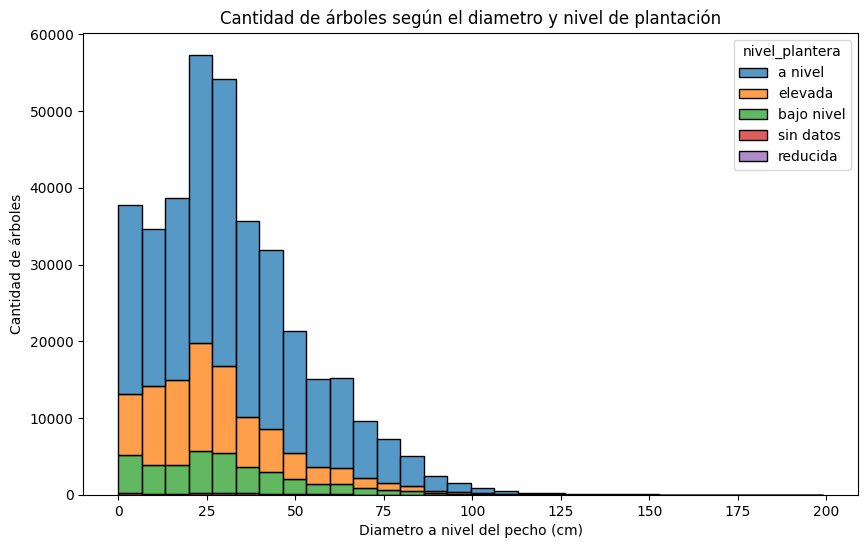

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=arbolado,
    x="diametro_altura_pecho",
    hue="nivel_plantera",
    multiple="stack",
    bins=30
)
plt.title("Cantidad de árboles según el diametro y nivel de plantación")
plt.xlabel("Diametro a nivel del pecho (cm)")
plt.ylabel("Cantidad de árboles")
plt.show()

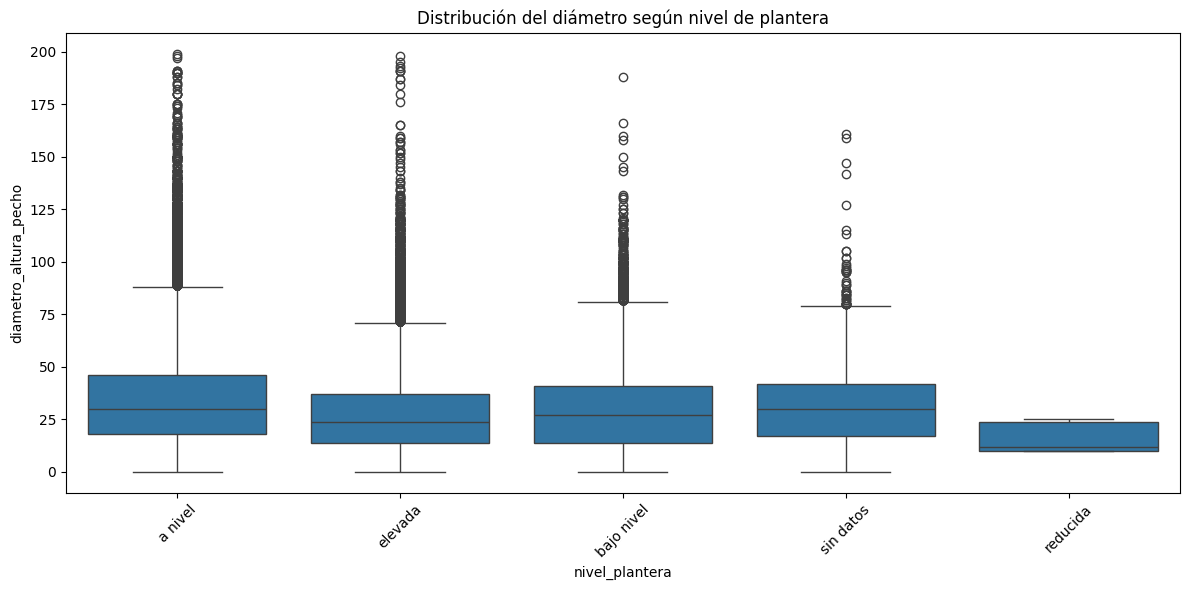

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=arbolado, x='nivel_plantera', y='diametro_altura_pecho')
plt.xticks(rotation=45)
plt.title('Distribución del diámetro según nivel de plantera')
plt.tight_layout()
plt.show()